<a href="https://colab.research.google.com/github/kijac/26_1_EEE_Project/blob/test/training_yolo_v10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## [Cell 1] 환경 설치 및 GPU 확인

In [ ]:
!pip install ultralytics roboflow -q

import os, shutil, yaml, glob
from pathlib import Path
from ultralytics import YOLO
import torch

print(f"PyTorch 버전: {torch.__version__}")
print(f"GPU 사용 가능: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU 이름: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️  런타임 > 런타임 유형 변경 > T4 GPU 선택 필요")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 77.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch 버전: 2.10.0+cu128
GPU 사용 가능: True
GPU 이름: Tesla T4


## [Cell 2] 구글 드라이브 마운트 (준비중)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_BASE = '/content/drive/MyDrive/PPE_Detection'
os.makedirs(DRIVE_BASE, exist_ok=True)
print(f"✅ 마운트 완료: {DRIVE_BASE}")

Mounted at /content/drive
✅ 마운트 완료: /content/drive/MyDrive/PPE_Detection


## [Cell 3-A] Roboflow API 다운로드 (준비중)

In [ ]:
# from roboflow import Roboflow

# RF_API_KEY   = "YOUR_API_KEY"
# RF_WORKSPACE = "YOUR_WORKSPACE"
# RF_PROJECT   = "YOUR_PROJECT_NAME"
# RF_VERSION   = 1

# rf = Roboflow(api_key=RF_API_KEY)
# project = rf.workspace(RF_WORKSPACE).project(RF_PROJECT)
# rf_dataset = project.version(RF_VERSION).download(
#     "yolov8",
#     location="/content/datasets/roboflow"
# )
# print(f"✅ 다운로드 완료: {rf_dataset.location}")

## [Cell 3-B] zip 파일 직접 업로드 (준비중)

In [ ]:
# Kaggle 다운로드 또는 직접 촬영 사진
# zip 구조:
#   dataset.zip
#   ├── train/images/, train/labels/
#   ├── valid/images/, valid/labels/
#   └── (data.yaml 없어도 됨)

from google.colab import files
import zipfile

print("zip 파일 업로드 (여러 개 가능)")
uploaded = files.upload()

for zip_name in uploaded.keys():
    extract_path = f"/content/datasets/{Path(zip_name).stem}"
    os.makedirs(extract_path, exist_ok=True)
    with zipfile.ZipFile(zip_name, 'r') as zf:
        zf.extractall(extract_path)
    print(f"✅ 압축 해제: {extract_path}")
    os.remove(zip_name)

zip 파일 업로드 (여러 개 가능)


Saving construction safety.v1i.yolov8 (1).zip to construction safety.v1i.yolov8 (1).zip
✅ 압축 해제: /content/datasets/construction safety.v1i.yolov8 (1)


In [ ]:
# Cell 1~3 한번에 재실행

import os, yaml
from ultralytics import YOLO
import torch

# 실제 경로로 직접 지정
DATASET_DIR = "/content/datasets/construction safety.v1i.yolov8 (1)"
yaml_path   = f"{DATASET_DIR}/data.yaml"

# data.yaml 확인
with open(yaml_path) as f:
    data = yaml.safe_load(f)

print(f"원본 클래스: {data['names']}")
print(f"원본 경로: {data.get('path', '없음')}")

원본 클래스: ['helmet', 'no-helmet', 'no-vest', 'person', 'vest']
원본 경로: 없음


In [ ]:
# 현재 클래스 순서
# 0: helmet
# 1: no-helmet  → 제거
# 2: no-vest    → 제거
# 3: person
# 4: vest

# 새 클래스 순서
# 0: person
# 1: helmet
# 2: vest

old_to_new = {
    3: 0,   # person    → 0
    0: 1,   # helmet    → 1
    4: 2,   # vest      → 2
    # 1(no-helmet), 2(no-vest) → None (제거)
}

TARGET_NAMES = ['person', 'helmet', 'vest']
TARGET_NC    = 3

print(f"ID 매핑: {old_to_new}")
print(f"제거: no-helmet(1), no-vest(2)")

ID 매핑: {3: 0, 0: 1, 4: 2}
제거: no-helmet(1), no-vest(2)


현재 순서: ['helmet', 'no-helmet', 'no-vest', 'person', 'vest']
현재 매핑: {'helmet': 0, 'no-helmet': 1, 'no-vest': 2, 'person': 3, 'vest': 4}

ID 매핑: {3: 0, 0: 1, 4: 2}
(없는 클래스는 제거됩니다)


In [ ]:
def convert_labels(dataset_dir, old_to_new):
    splits = ['train', 'valid', 'test']
    stats  = {'kept': 0, 'removed': 0, 'files': 0}

    for split in splits:
        label_dir = Path(dataset_dir) / split / 'labels'
        if not label_dir.exists():
            # valid 대신 val 폴더일 수도 있음
            label_dir = Path(dataset_dir).parent / split / 'labels'
        if not label_dir.exists():
            continue

        for lbl_file in label_dir.glob('*.txt'):
            with open(lbl_file) as f:
                lines = f.readlines()

            new_lines = []
            for line in lines:
                parts = line.strip().split()
                if not parts:
                    continue
                old_id = int(parts[0])
                new_id = old_to_new.get(old_id)

                if new_id is not None:
                    new_lines.append(
                        f"{new_id} {' '.join(parts[1:])}")
                    stats['kept'] += 1
                else:
                    stats['removed'] += 1

            with open(lbl_file, 'w') as f:
                f.write('\n'.join(new_lines))
            stats['files'] += 1

    print(f"✅ 라벨 변환 완료")
    print(f"   처리 파일: {stats['files']}개")
    print(f"   유지      : {stats['kept']}개")
    print(f"   제거      : {stats['removed']}개")

convert_labels(DATASET_DIR, old_to_new)

✅ 라벨 변환 완료
   처리 파일: 1206개
   유지      : 6703개
   제거      : 1021개


In [ ]:
data['names'] = TARGET_NAMES
data['nc']    = TARGET_NC
data['path']  = str(Path(yaml_path).parent)
data['train'] = 'train/images'
data['val']   = 'valid/images'
data['test']  = 'test/images'

with open(yaml_path, 'w') as f:
    yaml.dump(data, f, default_flow_style=False)

print("✅ data.yaml 수정 완료")
with open(yaml_path) as f:
    print(f.read())

✅ data.yaml 수정 완료
names:
- person
- helmet
- vest
nc: 3
path: /content/datasets/construction safety.v1i.yolov8 (1)
roboflow:
  license: CC BY 4.0
  project: construction-safety-gsnvb-egh4a
  url: https://app.roboflow.com/s-workspace-31kqe/construction-safety-gsnvb-egh4a/1
  version: 1
  workspace: s-workspace-31kqe
test: test/images
train: train/images
val: valid/images



In [ ]:
model = YOLO('yolov8n.pt')

model.train(
    data=yaml_path,
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    patience=20,
    name='ppe_v3_3class',
    project='/content/runs',
    cache=True,

    # 학습률
    cos_lr=True,
    optimizer='AdamW',
    lr0=0.01,
    lrf=0.001,
    warmup_epochs=5,

    # 증강
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=15.0,
    scale=0.5,
    mosaic=1.0,
    mixup=0.1,
    copy_paste=0.1,
    fliplr=0.5,
    flipud=0.0,
)

Ultralytics 8.4.31 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/datasets/construction safety.v1i.yolov8 (1)/data.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.001, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=ppe_v3_3class, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overl

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78e874268a10>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [ ]:
best    = YOLO('/content/runs/ppe_v3_3class/weights/best.pt')
metrics = best.val(data=yaml_path, verbose=False)

print("="*45)
print("📊 3클래스 학습 결과")
print("="*45)
print(f"mAP@50    : {metrics.box.map50:.4f}")
print(f"mAP@50-95 : {metrics.box.map:.4f}")
print(f"Precision : {metrics.box.mp:.4f}")
print(f"Recall    : {metrics.box.mr:.4f}")
print()
print("클래스별 AP@50:")
for i, cls in enumerate(TARGET_NAMES):
    if i < len(metrics.box.ap50):
        print(f"  {cls:10s}: {metrics.box.ap50[i]:.4f}")

Ultralytics 8.4.31 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1202.4±757.9 MB/s, size: 102.7 KB)
val: Scanning /content/datasets/construction safety.v1i.yolov8 (1)/valid/labels.cache... 119 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 119/119 31.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.3it/s 6.4s
                   all        119        614      0.929      0.866      0.936       0.56
Speed: 5.5ms preprocess, 14.5ms inference, 0.0ms loss, 5.7ms postprocess per image
Results saved to /content/runs/detect/val
📊 3클래스 학습 결과
mAP@50    : 0.9356
mAP@50-95 : 0.5597
Precision : 0.9291
Recall    : 0.8656

클래스별 AP@50:
  person    : 0.9447
  helmet    : 0.9405
  vest      : 0.9216


웹캠 테스트 시작 (3초 후 촬영)


<IPython.core.display.Javascript object>

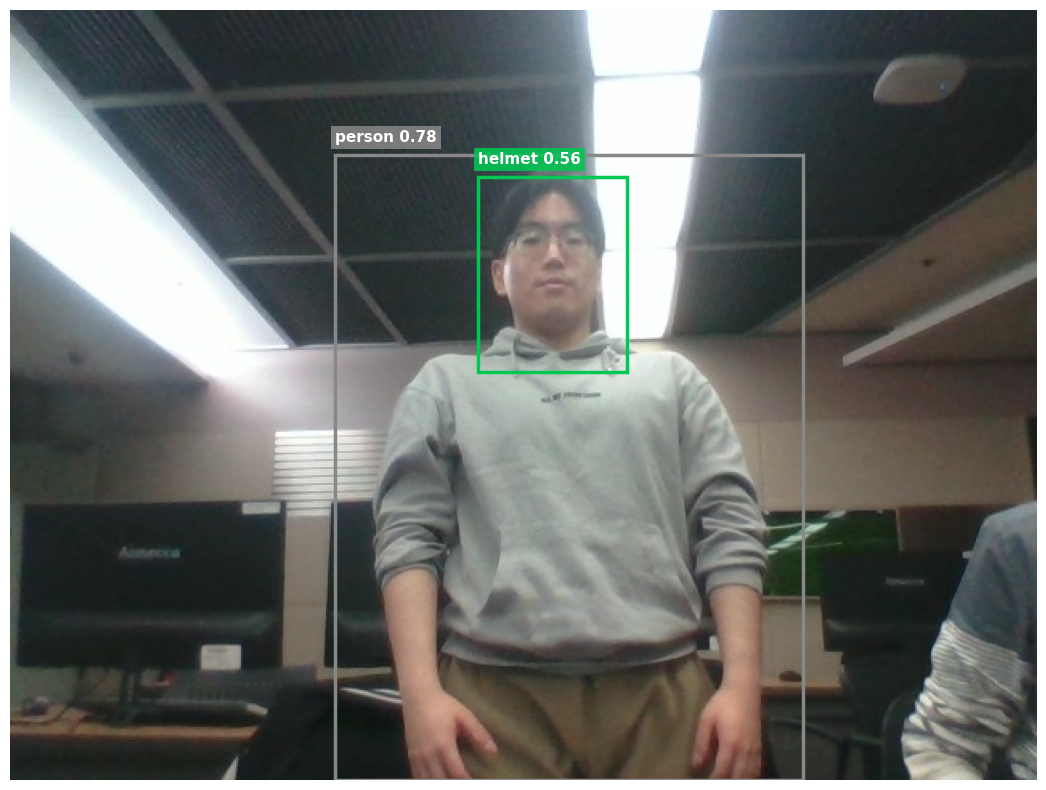


📊 감지 결과
  person    : 0.78
  helmet    : 0.56

🦺 안전 상태
  감지 인원: 1명
  안전모  : 1개 감지
  조끼    : 0개 감지

  안전모: ✅ 착용
  조끼  : ❌ 미착용 의심

  ⚠️  안전장비 미착용 감지!


In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import numpy as np
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import io

# 학습된 모델 로드
model = YOLO('/content/runs/ppe_v3_3class/weights/best.pt')

COLORS = {
    'person': '#888888',
    'helmet': '#00C853',
    'vest'  : '#2196F3',
}

def take_photo(sec=3):
    js = Javascript(f'''
        async function takePhoto() {{
            const div = document.createElement('div');
            const video = document.createElement('video');
            video.style.cssText = 'display:block;width:400px;';
            const stream = await navigator.mediaDevices
                                .getUserMedia({{video:true}});
            document.body.appendChild(div);
            div.appendChild(video);
            video.srcObject = stream;
            await video.play();

            const txt = document.createElement('p');
            txt.style.cssText = 'font-size:20px;font-weight:bold;';
            div.appendChild(txt);
            for (let i = {sec}; i > 0; i--) {{
                txt.textContent = i + '초 후 촬영...';
                await new Promise(r => setTimeout(r, 1000));
            }}
            txt.textContent = '📸 촬영!';

            const canvas = document.createElement('canvas');
            canvas.width  = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);
            stream.getTracks().forEach(t => t.stop());
            await new Promise(r => setTimeout(r, 500));
            div.remove();
            return canvas.toDataURL('image/jpeg', 0.9);
        }}
        takePhoto();
    ''')
    display(js)
    data = eval_js('takePhoto()')
    binary = b64decode(data.split(',')[1])
    return Image.open(io.BytesIO(binary))


def run_inference(img, conf=0.4):
    results = model.predict(
        source=np.array(img),
        conf=conf,
        verbose=False
    )

    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(img)

    boxes     = results[0].boxes
    detected  = [model.names[int(b.cls)] for b in boxes]

    for box in boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        cls_name = model.names[int(box.cls)]
        conf_val = float(box.conf)
        color    = COLORS.get(cls_name, '#FFFFFF')

        rect = patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=2.5,
            edgecolor=color,
            facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(
            x1, y1-8,
            f"{cls_name} {conf_val:.2f}",
            color='white', fontsize=11,
            fontweight='bold',
            bbox=dict(facecolor=color, alpha=0.85,
                      pad=3, edgecolor='none')
        )

    ax.axis('off')
    plt.tight_layout()
    plt.show()

    # 감지 결과
    print("\n" + "="*40)
    print("📊 감지 결과")
    print("="*40)
    if not boxes:
        print("  감지된 객체 없음")
    else:
        for box in boxes:
            cls_name = model.names[int(box.cls)]
            conf_val = float(box.conf)
            print(f"  {cls_name:10s}: {conf_val:.2f}")

    # 안전 상태 판단
    # person 기준으로 helmet/vest 착용 여부 판단
    print("\n" + "="*40)
    print("🦺 안전 상태")
    print("="*40)

    person_count = detected.count('person')
    helmet_count = detected.count('helmet')
    vest_count   = detected.count('vest')

    print(f"  감지 인원: {person_count}명")
    print(f"  안전모  : {helmet_count}개 감지")
    print(f"  조끼    : {vest_count}개 감지")
    print()

    if person_count == 0:
        print("  사람 감지 안됨")
    else:
        helmet_ok = helmet_count >= person_count
        vest_ok   = vest_count   >= person_count

        print(f"  안전모: {'✅ 착용' if helmet_ok else '❌ 미착용 의심'}")
        print(f"  조끼  : {'✅ 착용' if vest_ok   else '❌ 미착용 의심'}")

        if not helmet_ok or not vest_ok:
            print("\n  ⚠️  안전장비 미착용 감지!")
        else:
            print("\n  ✅ 안전장비 정상 착용!")


# 실행
print("웹캠 테스트 시작 (3초 후 촬영)")
img = take_photo(sec=3)
run_inference(img)

## [Cell 3-C] 구글 드라이브에서 불러오기 (세션 재시작해도 OK) (준비중)



In [ ]:
# Cell 1~3 한번에 재실행

import os, yaml
from ultralytics import YOLO
import torch

# 실제 경로로 직접 지정
DATASET_DIR = "/content/datasets/construction safety.v1i.yolov8(1)"
yaml_path   = f"{DATASET_DIR}/data.yaml"

# data.yaml 확인
with open(yaml_path) as f:
    data = yaml.safe_load(f)

print(f"원본 클래스: {data['names']}")
print(f"원본 경로: {data.get('path', '없음')}")

In [ ]:
# data.yaml 수정
name_fix = {'no-helmet': 'no_helmet', 'no-vest': 'no_vest'}
data['names'] = [name_fix.get(n, n) for n in data['names']]
data['path']  = DATASET_DIR
data['train'] = 'train/images'
data['val']   = 'valid/images'
data['test']  = 'test/images'

with open(yaml_path, 'w') as f:
    yaml.dump(data, f, default_flow_style=False)

print(f"✅ 수정된 클래스: {data['names']}")
print(f"✅ nc: {data['nc']}")

In [ ]:
# 학습 실행
from ultralytics import YOLO
model = YOLO('yolov8n.pt')
model.train(
    data=yaml_path,
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    patience=15,
    name='ppe_v1_test',
    project='/content/runs',
    cache=True,
    flipud=0.0,
    fliplr=0.5,
    mosaic=1.0,
    degrees=10.0,
)

NameError: name 'YOLO' is not defined

In [ ]:
# Colab에서 웹캠 영상 캡처 후 추론
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import numpy as np
import cv2
from ultralytics import YOLO
from PIL import Image
import io

model = YOLO('/content/runs/ppe_v1_test/weights/best.pt')

# 웹캠 캡처 자바스크립트
def take_photo():
    js = Javascript('''
        async function takePhoto() {
            const div = document.createElement('div');
            const video = document.createElement('video');
            video.style.display = 'block';
            const stream = await navigator.mediaDevices.getUserMedia({video: true});
            document.body.appendChild(div);
            div.appendChild(video);
            video.srcObject = stream;
            await video.play();

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;

            // 3초 후 캡처
            await new Promise(r => setTimeout(r, 3000));
            canvas.getContext('2d').drawImage(video, 0, 0);
            stream.getTracks().forEach(t => t.stop());
            div.remove();
            return canvas.toDataURL('image/jpeg', 0.8);
        }
        takePhoto();
    ''')
    display(js)
    data = eval_js('takePhoto()')
    binary = b64decode(data.split(',')[1])
    return Image.open(io.BytesIO(binary))

print("3초 후 웹캠 캡처됩니다...")
img = take_photo()

# 추론
results = model.predict(source=np.array(img),
                        conf=0.4, verbose=False)

# 결과 시각화
import matplotlib.pyplot as plt
import matplotlib.patches as patches

COLORS = {
    'helmet'   : '#00C853',
    'no_helmet': '#FF1744',
    'vest'     : '#2196F3',
    'no_vest'  : '#FF9100'
}

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(img)

for box in results[0].boxes:
    x1, y1, x2, y2 = box.xyxy[0].tolist()
    cls_name = model.names[int(box.cls)]
    conf = float(box.conf)
    color = COLORS.get(cls_name, 'white')

    rect = patches.Rectangle(
        (x1, y1), x2-x1, y2-y1,
        linewidth=2.5, edgecolor=color, facecolor='none'
    )
    ax.add_patch(rect)
    ax.text(x1, y1-8, f"{cls_name} {conf:.2f}",
            color='white', fontsize=10,
            bbox=dict(facecolor=color, alpha=0.8, pad=2))

ax.axis('off')
plt.tight_layout()
plt.show()

print("\n감지 결과:")
for box in results[0].boxes:
    print(f"  {model.names[int(box.cls)]}: {float(box.conf):.2f}")

ModuleNotFoundError: No module named 'ultralytics'

In [ ]:
import os, shutil
from pathlib import Path

def oversample_class(dataset_dir, class_id, target_count):
    """
    특정 클래스가 포함된 이미지를
    target_count만큼 복제해서 증강
    """
    img_dir = Path(dataset_dir)/'train'/'images'
    lbl_dir = Path(dataset_dir)/'train'/'labels'

    # 해당 클래스 포함된 이미지 찾기
    target_imgs = []
    for lbl_file in lbl_dir.glob('*.txt'):
        with open(lbl_file) as f:
            classes = [int(l.split()[0]) for l in f if l.strip()]
        if class_id in classes:
            target_imgs.append(lbl_file.stem)

    print(f"클래스 {class_id} 포함 이미지: {len(target_imgs)}장")

    # 목표 수량까지 복제
    current = len(target_imgs)
    copy_count = 0
    while current + copy_count < target_count:
        for stem in target_imgs:
            if current + copy_count >= target_count:
                break
            # 이미지 복제
            for ext in ['.jpg', '.jpeg', '.png']:
                src_img = img_dir / (stem + ext)
                if src_img.exists():
                    dst_img = img_dir / f"os_{copy_count:05d}{ext}"
                    shutil.copy2(src_img, dst_img)
                    break
            # 라벨 복제
            src_lbl = lbl_dir / (stem + '.txt')
            dst_lbl = lbl_dir / f"os_{copy_count:05d}.txt"
            shutil.copy2(src_lbl, dst_lbl)
            copy_count += 1

    print(f"✅ {copy_count}장 복제 완료 → 총 {current+copy_count}장")

DATASET_DIR = "/content/datasets/construction safety.v1i.yolov8"

# no_helmet (class_id=1) → 600장까지 오버샘플링
oversample_class(DATASET_DIR, class_id=1, target_count=600)

클래스 1 포함 이미지: 49장
✅ 551장 복제 완료 → 총 600장


In [ ]:
model.train(
    data=yaml_path,
    epochs=100,
    imgsz=640,
    batch=16,
    device=0,
    patience=20,
    name='ppe_v2_augmented',
    project='/content/runs',
    cache=True,

    # 증강 강화
    hsv_h=0.015,      # 색조 변화 (조끼 색상 다양화)
    hsv_s=0.7,        # 채도 변화
    hsv_v=0.4,        # 밝기 변화 (조명 환경 다양화)
    degrees=15.0,     # 회전 ±15도
    translate=0.1,    # 이동
    scale=0.5,        # 크기 변화
    shear=5.0,        # 기울기
    perspective=0.0005, # 원근감 변화
    flipud=0.0,
    fliplr=0.5,
    mosaic=1.0,       # 모자이크 (여러 이미지 합성)
    mixup=0.1,        # mixup 증강 추가
    copy_paste=0.1,   # 객체 복사 붙여넣기
)

Ultralytics 8.4.31 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/construction safety.v1i.yolov8/data.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=/content/runs/ppe_v1_test/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=ppe_v2_augmented, nbs=64, nms=False, opset=None, optimiz

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78e85c71ad50>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

웹캠 테스트 시작 (3초 후 촬영)


<IPython.core.display.Javascript object>

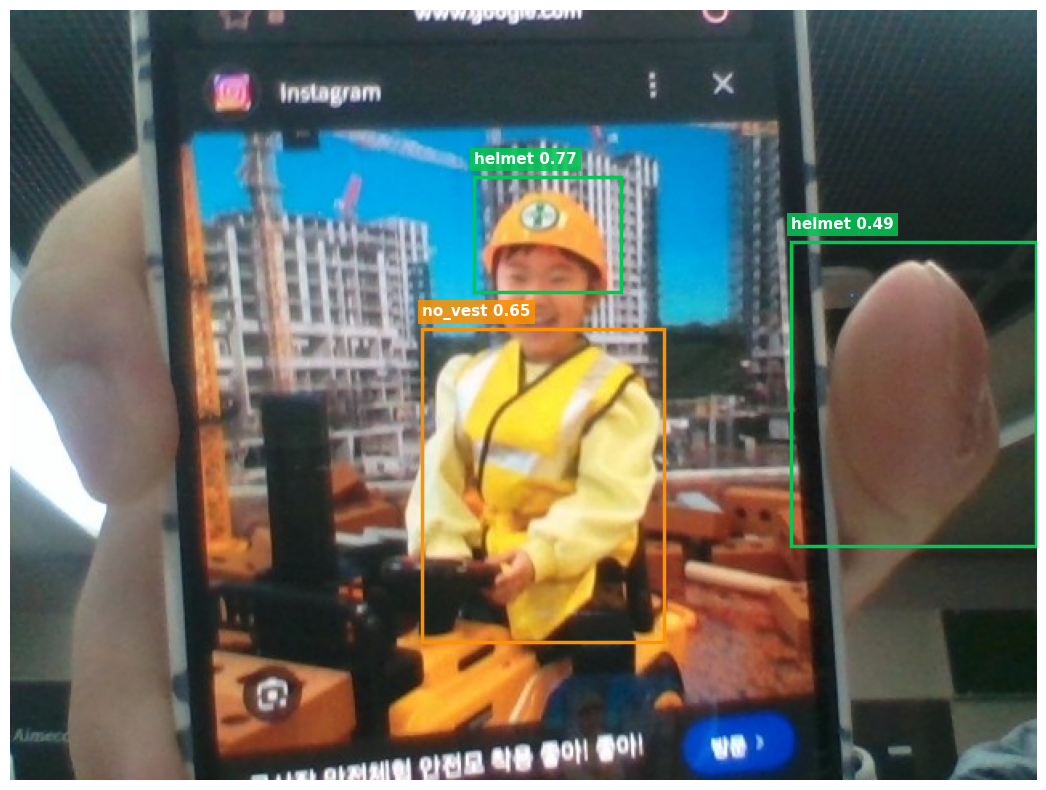


📊 감지 결과
  helmet      : 0.77
  no_vest     : 0.65
  helmet      : 0.49

🦺 안전 상태
  안전모: ✅ 착용
  조끼  : ❌ 미착용

  ⚠️  안전장비 미착용 감지!


In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import numpy as np
import cv2
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import io

# 모델 로드 (경로 확인)
model = YOLO('/content/runs/ppe_v2_augmented/weights/best.pt')

COLORS = {
    'helmet'   : '#00C853',
    'no_helmet': '#FF1744',
    'no_vest'  : '#FF9100',
    'vest'     : '#2196F3',
}

def take_photo(sec=3):
    js = Javascript(f'''
        async function takePhoto() {{
            const div = document.createElement('div');
            const video = document.createElement('video');
            video.style.cssText = 'display:block;width:400px;';
            const stream = await navigator.mediaDevices
                                .getUserMedia({{video:true}});
            document.body.appendChild(div);
            div.appendChild(video);
            video.srcObject = stream;
            await video.play();

            // 카운트다운 표시
            const txt = document.createElement('p');
            txt.style.cssText = 'font-size:20px;font-weight:bold;';
            div.appendChild(txt);
            for (let i = {sec}; i > 0; i--) {{
                txt.textContent = i + '초 후 촬영...';
                await new Promise(r => setTimeout(r, 1000));
            }}
            txt.textContent = '📸 촬영!';

            const canvas = document.createElement('canvas');
            canvas.width  = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);
            stream.getTracks().forEach(t => t.stop());

            await new Promise(r => setTimeout(r, 500));
            div.remove();
            return canvas.toDataURL('image/jpeg', 0.9);
        }}
        takePhoto();
    ''')
    display(js)
    data = eval_js('takePhoto()')
    binary = b64decode(data.split(',')[1])
    return Image.open(io.BytesIO(binary))


def run_inference(img):
    results = model.predict(
        source=np.array(img),
        conf=0.4,
        verbose=False
    )

    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(img)

    detections = results[0].boxes
    if len(detections) == 0:
        ax.set_title("감지된 객체 없음", fontsize=14)
    else:
        for box in detections:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            cls_name = model.names[int(box.cls)]
            conf     = float(box.conf)
            color    = COLORS.get(cls_name, '#FFFFFF')

            rect = patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=2.5,
                edgecolor=color,
                facecolor='none'
            )
            ax.add_patch(rect)
            ax.text(
                x1, y1-8,
                f"{cls_name} {conf:.2f}",
                color='white',
                fontsize=11,
                fontweight='bold',
                bbox=dict(
                    facecolor=color,
                    alpha=0.85,
                    pad=3,
                    edgecolor='none'
                )
            )

    ax.axis('off')
    plt.tight_layout()
    plt.show()

    # 텍스트 결과
    print("\n" + "="*40)
    print("📊 감지 결과")
    print("="*40)
    if len(detections) == 0:
        print("  감지된 객체 없음")
    else:
        for box in detections:
            cls_name = model.names[int(box.cls)]
            conf     = float(box.conf)
            print(f"  {cls_name:12s}: {conf:.2f}")

    # 안전 상태 판단
    print("\n" + "="*40)
    print("🦺 안전 상태")
    print("="*40)
    detected = [model.names[int(b.cls)] for b in detections]

    helmet_ok = 'helmet' in detected
    vest_ok   = 'vest'   in detected

    print(f"  안전모: {'✅ 착용' if helmet_ok else '❌ 미착용'}")
    print(f"  조끼  : {'✅ 착용' if vest_ok   else '❌ 미착용'}")

    if not helmet_ok or not vest_ok:
        print("\n  ⚠️  안전장비 미착용 감지!")


# 실행
print("웹캠 테스트 시작 (3초 후 촬영)")
img = take_photo(sec=3)
run_inference(img)

In [ ]:
import zipfile

# 드라이브에 올려둔 zip 경로 입력
DRIVE_ZIPS = [
    "/content/drive/MyDrive/PPE_Detection/kaggle_ppe.zip",
    "/content/drive/MyDrive/PPE_Detection/custom_photos.zip",
]

for zip_path in DRIVE_ZIPS:
    if not os.path.exists(zip_path):
        print(f"⚠️  없음 스킵: {zip_path}")
        continue
    extract_path = f"/content/datasets/{Path(zip_path).stem}"
    os.makedirs(extract_path, exist_ok=True)
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(extract_path)
    print(f"✅ 압축 해제: {extract_path}")

## [Cell 4] 클래스 매핑 설정

In [ ]:
# Cell 3: data.yaml 수정 (하이픈만 처리)
yaml_path = f"{DATASET_DIR}/data.yaml"

with open(yaml_path) as f:
    data = yaml.safe_load(f)

print(f"원본 클래스: {data['names']}")

# 하이픈 → 언더스코어
name_fix = {'no-helmet': 'no_helmet', 'no-vest': 'no_vest'}
data['names'] = [name_fix.get(n, n) for n in data['names']]

# 절대 경로 설정
data['path']  = DATASET_DIR
data['train'] = 'train/images'
data['val']   = 'valid/images'
data['test']  = 'test/images'

with open(yaml_path, 'w') as f:
    yaml.dump(data, f, default_flow_style=False)

print(f"수정된 클래스: {data['names']}")
print(f"nc: {data['nc']}")


In [ ]:
# Cell 4: 학습
model = YOLO('yolov8n.pt')
model.train(
    data=yaml_path,
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    patience=15,
    name='ppe_v1_test',
    project='/content/runs',
    cache=True,
    flipud=0.0,
    fliplr=0.5,
    mosaic=1.0,
    degrees=10.0,
)

In [ ]:
# Cell 5: 결과 확인
best = YOLO('/content/runs/ppe_v1_test/weights/best.pt')
metrics = best.val(data=yaml_path, verbose=False)

classes = data['names']
print(f"\nmAP@50    : {metrics.box.map50:.4f}")
print(f"mAP@50-95 : {metrics.box.map:.4f}")
print("\n클래스별 AP@50:")
for i, cls in enumerate(classes):
    if i < len(metrics.box.ap50):
        print(f"  {cls:12s}: {metrics.box.ap50[i]:.4f}")

## [Cell 7] data.yaml 생성

In [ ]:
yaml_path = f"{OUTPUT_DIR}/data.yaml"
with open(yaml_path, 'w') as f:
    yaml.dump({
        'path' : OUTPUT_DIR,
        'train': 'train/images',
        'val'  : 'valid/images',
        'test' : 'test/images',
        'nc'   : len(TARGET_CLASSES),
        'names': TARGET_CLASSES
    }, f, default_flow_style=False)

print("✅ data.yaml 생성 완료")
with open(yaml_path) as f:
    print(f.read())

## [Cell 8] 데이터 검증 + 시각화

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from collections import Counter

def validate(out_dir, tgt_cls):
    out_dir = Path(out_dir)
    COLORS = {'helmet':'#00C853','no_helmet':'#FF1744',
               'vest':'#2196F3','no_vest':'#FF9100'}
    for split in ['train','valid','test']:
        imgs = list((out_dir/split/'images').glob('*.*'))
        cnts = Counter()
        empty = 0
        for img in imgs:
            lbl = out_dir/split/'labels'/(img.stem+'.txt')
            if lbl.exists() and lbl.stat().st_size > 0:
                for line in lbl.read_text().splitlines():
                    cid = int(line.split()[0])
                    if cid < len(tgt_cls):
                        cnts[tgt_cls[cid]] += 1
            else:
                empty += 1
        print(f"\n[{split.upper()}] {len(imgs):,}장 (라벨없음:{empty})")
        for c in tgt_cls:
            bar = '█'*(cnts.get(c,0)//50)
            print(f"  {c:12s}: {cnts.get(c,0):5,}  {bar}")

    # 샘플 시각화
    sample_imgs = list((out_dir/'train'/'images').glob('*.*'))[:6]
    fig, axes = plt.subplots(2, 3, figsize=(15,8))
    for i, img_path in enumerate(sample_imgs):
        img = Image.open(img_path).convert('RGB')
        w, h = img.size
        axes.flatten()[i].imshow(img)
        lbl = out_dir/'train'/'labels'/(img_path.stem+'.txt')
        if lbl.exists():
            for line in lbl.read_text().splitlines():
                p = line.split()
                if len(p)<5: continue
                cid,cx,cy,bw,bh = int(p[0]),*map(float,p[1:5])
                cls = tgt_cls[cid] if cid<len(tgt_cls) else str(cid)
                x1,y1 = (cx-bw/2)*w, (cy-bh/2)*h
                rect = patches.Rectangle(
                    (x1,y1),bw*w,bh*h,
                    linewidth=2,edgecolor=COLORS.get(cls,'white'),
                    facecolor='none')
                axes.flatten()[i].add_patch(rect)
                axes.flatten()[i].text(
                    x1,y1-5,cls,color='white',fontsize=7,
                    bbox=dict(facecolor=COLORS.get(cls,'gray'),
                              alpha=0.7,pad=0.2))
        axes.flatten()[i].axis('off')
    plt.tight_layout()
    plt.show()

validate(OUTPUT_DIR, TARGET_CLASSES)

## [Cell 9] 학습 실행 (CUDA 필요)

In [ ]:
# model = YOLO('yolov8n.pt')
# results = model.train(
#     data=yaml_path,
#     epochs=100,
#     imgsz=640,
#     batch=16,          # 메모리 부족 시 8로 낮출 것
#     device=0,
#     patience=20,       # Early stopping
#     name='ppe_v1',
#     project='/content/runs',
#     cache=True,
#     flipud=0.0,        # 상하반전 OFF
#     fliplr=0.5,
#     mosaic=1.0,
#     degrees=10.0,
# )
# print(f"✅ 학습 완료")

## [Cell 10] 결과 시각화

In [ ]:
import pandas as pd

df = pd.read_csv('/content/runs/ppe_v1/results.csv')
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(2, 3, figsize=(16,8))
plots = [
    ('train/box_loss','val/box_loss','Box Loss',axes[0,0]),
    ('train/cls_loss','val/cls_loss','Class Loss',axes[0,1]),
    ('train/dfl_loss','val/dfl_loss','DFL Loss',axes[0,2]),
    ('metrics/precision(B)',None,'Precision',axes[1,0]),
    ('metrics/recall(B)',None,'Recall',axes[1,1]),
    ('metrics/mAP50(B)','metrics/mAP50-95(B)','mAP',axes[1,2]),
]
for tc, vc, title, ax in plots:
    if tc in df.columns:
        ax.plot(df['epoch'], df[tc], label='train', color='#2196F3')
    if vc and vc in df.columns:
        ax.plot(df['epoch'], df[vc], label='val', color='#FF5722')
    ax.set_title(title); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/training_results.png', dpi=150)
plt.show()

## [Cell 11] ONNX Export + 드라이브 저장

In [ ]:
from datetime import datetime

best = YOLO('/content/runs/ppe_v1/weights/best.pt')
best.export(format='onnx', imgsz=640,
            simplify=True, dynamic=False, opset=11)

ts = datetime.now().strftime("%Y%m%d_%H%M")
save_dir = f"{DRIVE_BASE}/models/{ts}_ppe_v1"
os.makedirs(save_dir, exist_ok=True)

for src, dst in [
    ('/content/runs/ppe_v1/weights/best.pt',   f'{save_dir}/best.pt'),
    ('/content/runs/ppe_v1/weights/best.onnx', f'{save_dir}/best.onnx'),
    ('/content/training_results.png',           f'{save_dir}/results.png'),
    (yaml_path,                                 f'{save_dir}/data.yaml'),
]:
    if os.path.exists(src):
        shutil.copy2(src, dst)
        print(f"저장: {dst}")

print(f"\n✅ 완료! 경로: {save_dir}")
print("📌 다음: best.onnx → Hailo .hef 변환")

## [Cell 12] YOLOv10 환경 설치

In [ ]:
# YOLOv10은 별도 패키지 필요
!pip install git+https://github.com/THU-MIG/yolov10.git -q
!pip install huggingface_hub -q

from ultralytics import YOLOv10
print("✅ YOLOv10 설치 완료")

## [Cell 13] YOLOv10 학습

In [ ]:
# YOLOv10n (nano) - YOLOv8n과 동급 크기
v10_model = YOLOv10('yolov10n.pt')

v10_results = v10_model.train(
    data=yaml_path,
    epochs=100,
    imgsz=640,
    batch=16,
    device=0,
    patience=20,
    name='ppe_v10n',
    project='/content/runs',
    cache=True,
    flipud=0.0,
    fliplr=0.5,
    mosaic=1.0,
    degrees=10.0,
)
print("✅ YOLOv10 학습 완료")

## [Cell 14] YOLOv8n vs YOLOv10n 성능 비교

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import time
import numpy as np
from PIL import Image
from ultralytics import YOLO, YOLOv10

# ── 모델 로드 ──────────────────────────────
v8_model  = YOLO('/content/runs/ppe_v1/weights/best.pt')
v10_model = YOLOv10('/content/runs/ppe_v10n/weights/best.pt')

# ── mAP 비교 ───────────────────────────────
print("📊 mAP 측정 중...")
v8_metrics  = v8_model.val(data=yaml_path,  verbose=False)
v10_metrics = v10_model.val(data=yaml_path, verbose=False)

results = {
    'YOLOv8n' : {
        'mAP50'    : v8_metrics.box.map50,
        'mAP50_95' : v8_metrics.box.map,
        'Precision': v8_metrics.box.mp,
        'Recall'   : v8_metrics.box.mr,
    },
    'YOLOv10n': {
        'mAP50'    : v10_metrics.box.map50,
        'mAP50_95' : v10_metrics.box.map,
        'Precision': v10_metrics.box.mp,
        'Recall'   : v10_metrics.box.mr,
    }
}

# ── 추론 속도 비교 (CPU 시뮬레이션) ────────
print("\n⏱️  추론 속도 측정 중...")
test_imgs = list(Path(OUTPUT_DIR).glob('test/images/*.*'))[:50]

def measure_fps(model, img_list, n_runs=50):
    # 워밍업
    for img in img_list[:5]:
        model.predict(str(img), verbose=False)
    # 측정
    times = []
    for img in img_list[:n_runs]:
        t0 = time.perf_counter()
        model.predict(str(img), verbose=False)
        times.append(time.perf_counter() - t0)
    avg_ms = np.mean(times) * 1000
    fps    = 1.0 / np.mean(times)
    return avg_ms, fps

v8_ms,  v8_fps  = measure_fps(v8_model,  test_imgs)
v10_ms, v10_fps = measure_fps(v10_model, test_imgs)

results['YOLOv8n' ]['ms_per_frame'] = v8_ms
results['YOLOv8n' ]['FPS_CPU']      = v8_fps
results['YOLOv10n']['ms_per_frame'] = v10_ms
results['YOLOv10n']['FPS_CPU']      = v10_fps

# ── 모델 크기 비교 ──────────────────────────
v8_size  = os.path.getsize('/content/runs/ppe_v1/weights/best.pt')  / 1e6
v10_size = os.path.getsize('/content/runs/ppe_v10n/weights/best.pt') / 1e6

results['YOLOv8n' ]['model_size_MB'] = v8_size
results['YOLOv10n']['model_size_MB'] = v10_size

# ── 결과 출력 ───────────────────────────────
print("\n" + "="*55)
print("📊 YOLOv8n vs YOLOv10n 비교 결과")
print("="*55)
metrics_to_show = [
    ('mAP50',        'mAP@50',       '.4f'),
    ('mAP50_95',     'mAP@50-95',    '.4f'),
    ('Precision',    'Precision',    '.4f'),
    ('Recall',       'Recall',       '.4f'),
    ('ms_per_frame', 'ms/frame(CPU)','.1f'),
    ('FPS_CPU',      'FPS(CPU)',      '.1f'),
    ('model_size_MB','크기(MB)',      '.1f'),
]
print(f"  {'지표':<16} {'YOLOv8n':>10} {'YOLOv10n':>10}")
print("  " + "-"*38)
for key, label, fmt in metrics_to_show:
    v8_val  = results['YOLOv8n'][key]
    v10_val = results['YOLOv10n'][key]
    print(f"  {label:<16} {v8_val:>10{fmt}} {v10_val:>10{fmt}}")

## [Cell 15] 비교 시각화

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('YOLOv8n vs YOLOv10n 비교',
             fontsize=14, fontweight='bold')

models = ['YOLOv8n', 'YOLOv10n']
colors = ['#2196F3', '#FF5722']

# mAP 비교
ax = axes[0]
maps = [results[m]['mAP50'] for m in models]
bars = ax.bar(models, maps, color=colors, width=0.4)
ax.set_title('mAP@50')
ax.set_ylim(0, 1.0)
for bar, val in zip(bars, maps):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# FPS 비교
ax = axes[1]
fps_vals = [results[m]['FPS_CPU'] for m in models]
bars = ax.bar(models, fps_vals, color=colors, width=0.4)
ax.set_title('FPS (CPU 기준)')
for bar, val in zip(bars, fps_vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f'{val:.1f}', ha='center', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# 모델 크기 비교
ax = axes[2]
sizes = [results[m]['model_size_MB'] for m in models]
bars = ax.bar(models, sizes, color=colors, width=0.4)
ax.set_title('모델 크기 (MB)')
for bar, val in zip(bars, sizes):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.05,
            f'{val:.1f}MB', ha='center', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/v8_vs_v10_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ 비교 시각화 저장 완료")

## [Cell 16] 클래스별 상세 비교

In [ ]:
# 어떤 클래스에서 차이가 나는지 확인
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('클래스별 AP@50 비교',
             fontsize=13, fontweight='bold')

x = np.arange(len(TARGET_CLASSES))
width = 0.35

for ax, (model_name, metrics) in zip(
        axes, [('YOLOv8n', v8_metrics),
               ('YOLOv10n', v10_metrics)]):

    ap_per_class = metrics.box.ap50
    bars = ax.bar(x, ap_per_class[:len(TARGET_CLASSES)],
                  color=['#00C853','#FF1744','#2196F3','#FF9100'],
                  width=0.5)
    ax.set_title(f'{model_name} 클래스별 AP@50')
    ax.set_xticks(x)
    ax.set_xticklabels(TARGET_CLASSES, rotation=15)
    ax.set_ylim(0, 1.0)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, ap_per_class):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('/content/class_ap_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

## [Cell 17] YOLOv10 ONNX Export + 저장

In [ ]:
from datetime import datetime

# YOLOv10 ONNX export
v10_best = YOLOv10('/content/runs/ppe_v10n/weights/best.pt')
v10_best.export(
    format='onnx',
    imgsz=640,
    simplify=True,
    dynamic=False,
    opset=11        # Hailo 호환
)
print("✅ YOLOv10 ONNX export 완료")

# 드라이브 저장
ts = datetime.now().strftime("%Y%m%d_%H%M")
save_dir = f"{DRIVE_BASE}/models/{ts}_comparison"
os.makedirs(save_dir, exist_ok=True)

files_to_save = [
    ('/content/runs/ppe_v1/weights/best.pt',
     f'{save_dir}/v8n_best.pt'),
    ('/content/runs/ppe_v1/weights/best.onnx',
     f'{save_dir}/v8n_best.onnx'),
    ('/content/runs/ppe_v10n/weights/best.pt',
     f'{save_dir}/v10n_best.pt'),
    ('/content/runs/ppe_v10n/weights/best.onnx',
     f'{save_dir}/v10n_best.onnx'),
    ('/content/v8_vs_v10_comparison.png',
     f'{save_dir}/comparison.png'),
    ('/content/class_ap_comparison.png',
     f'{save_dir}/class_ap.png'),
]

for src, dst in files_to_save:
    if os.path.exists(src):
        shutil.copy2(src, dst)
        print(f"  저장: {Path(dst).name}")

print(f"\n✅ 전체 저장 완료: {save_dir}")
print("\n📌 다음 단계:")
print("  1. Hailo Model Zoo로 .hef 변환")
print("  2. 라즈베리파이에서 실측 FPS 측정")
print("  3. NMS 유무 실제 성능차 검증")